In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from datetime import datetime
from scipy import stats

# 1. Download the complete dataset directory (returns the local path)
dataset_path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Dataset downloaded to:", dataset_path)

# 2. Define the individual file paths inside that directory
train_file_path = os.path.join(dataset_path, "fraudTrain.csv")
test_file_path = os.path.join(dataset_path, "fraudTest.csv")

# 3. Load them into separate pandas DataFrames
print("Loading training set...")
df_train = pd.read_csv(train_file_path)

print("Loading test set...")
df_test = pd.read_csv(test_file_path)

# 4. Verify the shapes
print(f"\nTraining set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

Dataset downloaded to: C:\Users\charc\.cache\kagglehub\datasets\kartik2112\fraud-detection\versions\1
Loading training set...
Loading test set...

Training set shape: (1296675, 23)
Test set shape: (555719, 23)


## Data Preprocessing

In [2]:
# Merge the two dataframes for preprocessing & feature scaling
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

In [3]:
# Remove the unnecessary column
df = df.drop(columns=('Unnamed: 0'))

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [5]:
# Fix data types of date/datetime features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob']).dt.date

In [6]:
# Check null values
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   trans_date_trans_time  datetime64[ns]
 1   cc_num                 int64         
 2   merchant               object        
 3   category               object        
 4   amt                    float64       
 5   first                  object        
 6   last                   object        
 7   gender                 object        
 8   street                 object        
 9   city                   object        
 10  state                  object        
 11  zip                    int64         
 12  lat                    float64       
 13  long                   float64       
 14  city_pop               int64         
 15  job                    object        
 16  dob                    object        
 17  trans_num              object        
 18  unix_time             

In [9]:
# Fixing the 'merchant' feature
df['merchant'] = df['merchant'].str.removeprefix('fraud_')

In [10]:
# Split the columns by data type
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=object).columns.tolist()

## Exploratory Data Analysis

In [11]:
# Checking proportion of fraud vs non-fraud transactions
fraud_rate = (df['is_fraud'].value_counts(normalize=True) * 100)
print(f"Total fraud rate: {fraud_rate.loc[1]:.2f}%")

Total fraud rate: 0.52%


### Univariate Analysis

In [12]:
# Check Skewness & Kurtosis
print('Skewness:')
for col in num_cols:
    print(col, ':', df[col].skew().round(2))

print('\nKurtosis:')
for col in num_cols:
    print(col, ':', df[col].kurt().round(2))

Skewness:
cc_num : 2.85
amt : 40.81
zip : 0.08
lat : -0.19
long : -1.15
city_pop : 5.59
unix_time : -0.02
merch_lat : -0.19
merch_long : -1.14
is_fraud : 13.75

Kurtosis:
cc_num : 6.18
amt : 4181.91
zip : -1.1
lat : 0.79
long : 1.84
city_pop : 37.57
unix_time : -1.2
merch_lat : 0.77
merch_long : 1.83
is_fraud : 186.94


In [13]:
# Shapiro-Wilk test to check the normality
stat, p = stats.shapiro(df[col].dropna().sample(min(5000, len(df))))
print('Normal' if p > 0.05 else 'Not normal')

Not normal


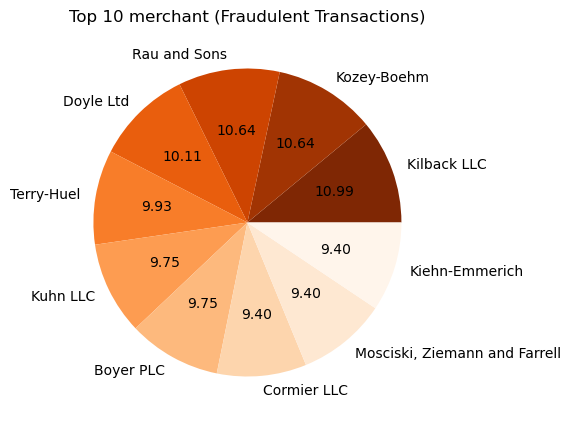

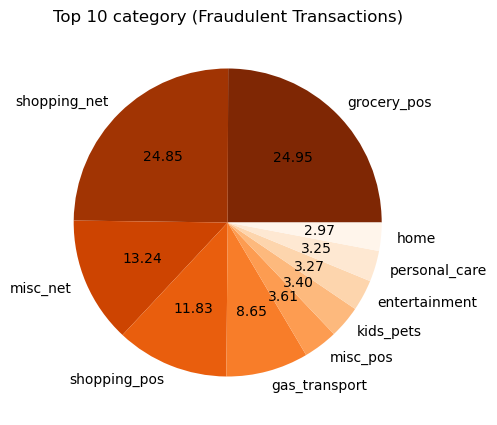

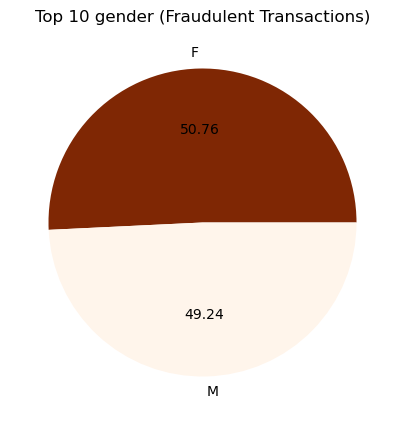

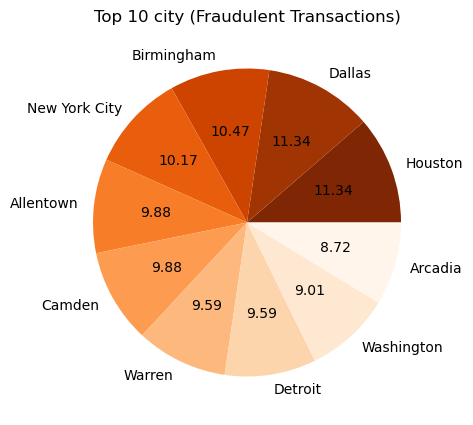

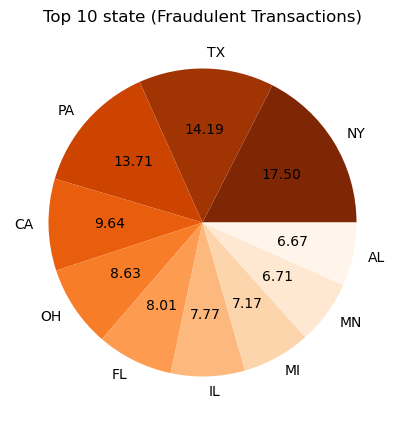

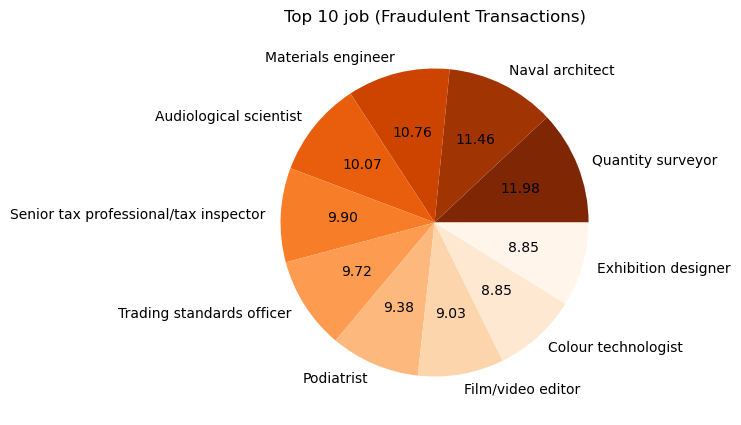

In [95]:
# Plotting ordinal categorical columns by fraudulent transactions (is_fraud = 1)
ord_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']
for col in ord_cols:
    plt.figure(figsize=(6, 5))
    (df.query("is_fraud == 1")[col].value_counts(normalize=True)*100).head(10).plot(
        kind='pie',
        autopct='%.2f',
        colormap='Oranges_r',
        title=f'Top 10 {col} (Fraudulent Transactions)'
    )
    plt.ylabel('')
    plt.show()

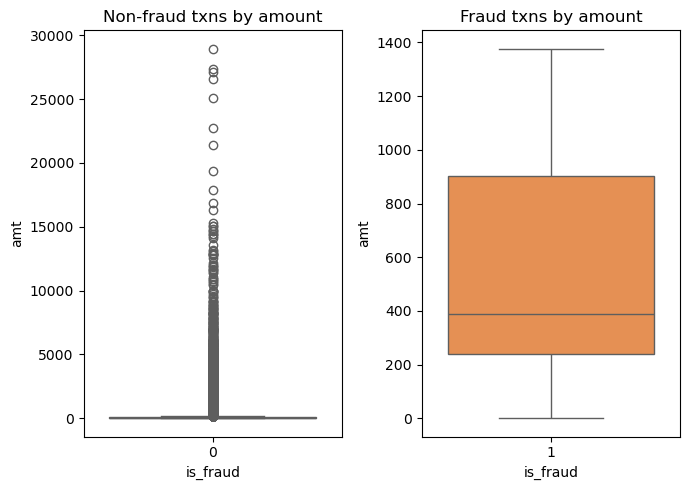

--- Non-Fraud Transactions ---
Q1: 9.61 | Q3: 82.56 | IQR: 72.95
Lower Bound: -4.80
Upper Bound: 24.02

--- Fraud Transactions ---
Q1: 240.075 | Q3: 902.365 | IQR: 662.29
Lower Bound: -120.04
Upper Bound: 600.19


In [102]:
# Spotting the outliers, IQR & median b/w fraud & non-fraud transactions
fig, ax = plt.subplots(1, 2, figsize=(7, 5))

sns.boxplot(data=df[df['is_fraud'] == 0], x='is_fraud', y='amt', ax=ax[0], hue='is_fraud', palette='Oranges', legend=False)
ax[0].set_title("Non-fraud txns by amount")
sns.boxplot(data=df[df['is_fraud'] == 1], x='is_fraud', y='amt', ax=ax[1], hue='is_fraud', palette='Oranges', legend=False)
ax[1].set_title("Fraud txns by amount")

plt.tight_layout()
plt.show()

# Calculating IQR, lower/upper bound for fraud & non-fraud transactions
legit_data = df[df['is_fraud'] == 0]['amt']

q1_legit = legit_data.quantile(0.25)
q3_legit = legit_data.quantile(0.75)
iqr_legit = q3_legit - q1_legit
lower_bound_legit = q1_legit - (1.5 * q1_legit)
upper_bound_legit = q1_legit + (1.5 * q1_legit)

print("--- Non-Fraud Transactions ---")
print(f"Q1: {q1_legit} | Q3: {q3_legit} | IQR: {iqr_legit}")
print(f"Lower Bound: {lower_bound_legit:.2f}")
print(f"Upper Bound: {upper_bound_legit:.2f}")

fraud_data = df[df['is_fraud'] == 1]['amt']

q1_fraud = fraud_data.quantile(0.25)
q3_fraud = fraud_data.quantile(0.75)
iqr_fraud = q3_fraud - q1_fraud
lower_bound_fraud = q1_fraud - (1.5 * q1_fraud)
upper_bound_fraud = q1_fraud + (1.5 * q1_fraud)

print("\n--- Fraud Transactions ---")
print(f"Q1: {q1_fraud} | Q3: {q3_fraud} | IQR: {iqr_fraud}")
print(f"Lower Bound: {lower_bound_fraud:.2f}")
print(f"Upper Bound: {upper_bound_fraud:.2f}")

### Bivariate/Multivariate Analysis

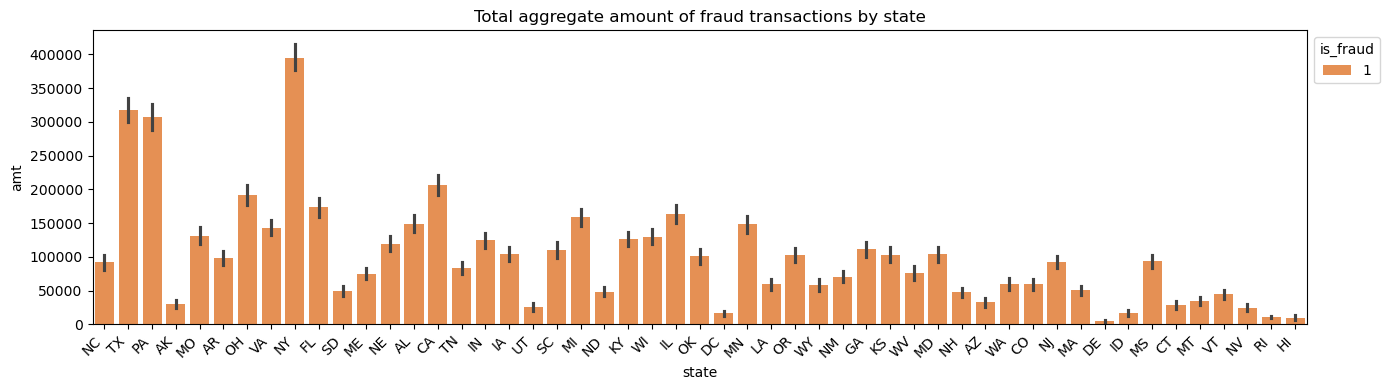

In [106]:
# Total aggregate amount of fraud transactions by state
plt.figure(figsize=(14,4))
ax = sns.barplot(data=df[df['is_fraud'] == 1], x='state', y='amt', hue='is_fraud', estimator=sum, palette='Oranges')
ax.set_title("Total aggregate amount of fraud transactions by state")
plt.xticks(rotation=45, ha='right')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [112]:
# Correlation Matrix
df.corr(numeric_only=True).style.background_gradient(cmap='Oranges')

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
cc_num,1.000000,0.001826,0.041504,-0.058744,-0.048429,-0.009118,0.000284,-0.058415,-0.048421,-0.001125
amt,0.001826,1.000000,0.001979,-0.000670,-0.000735,0.004921,-0.002411,-0.000613,-0.000711,0.209308
zip,0.041504,0.001979,1.000000,-0.114554,-0.909795,0.077601,0.001017,-0.113934,-0.908981,-0.002190
lat,-0.058744,-0.000670,-0.114554,1.000000,-0.014744,-0.154816,0.000741,0.993582,-0.014709,0.002904
long,-0.048429,-0.000735,-0.909795,-0.014744,1.000000,-0.052359,-0.000574,-0.014585,0.999118,0.001022
city_pop,-0.009118,0.004921,0.077601,-0.154816,-0.052359,1.000000,-0.001636,-0.153863,-0.052329,0.000325
unix_time,0.000284,-0.002411,0.001017,0.000741,-0.000574,-0.001636,1.000000,0.000696,-0.000571,-0.013329
merch_lat,-0.058415,-0.000613,-0.113934,0.993582,-0.014585,-0.153863,0.000696,1.000000,-0.014554,0.002778
merch_long,-0.048421,-0.000711,-0.908981,-0.014709,0.999118,-0.052329,-0.000571,-0.014554,1.000000,0.000999
is_fraud,-0.001125,0.209308,-0.002190,0.002904,0.001022,0.000325,-0.013329,0.002778,0.000999,1.000000


In [16]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [17]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

# ---Work in progress---